# 문제 4 — 연립방정식과 해의 판정 (가우스 소거·rank·행렬식·역행렬)

풀어야 하는 연립방정식은 다음과 같습니다. 해는 정수로 떨어집니다.

$$\begin{aligned}
3x_1 + x_2 + 2x_3 &= 11\\
x_1 + 4x_2 + x_3 &= 1\\
2x_1 - x_2 + 5x_3 &= 20
\end{aligned}$$

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 4-1 | **가우스 소거법을 직접 구현**해 풀고 **각 소거 단계의 첨가행렬을 모두 출력** | `gauss_eliminate` |
| 4-2 | 계수행렬과 첨가행렬의 rank 로 **해의 존재·유일성 판정**, 같을 때와 다를 때의 의미 설명 | `rank` |
| 4-3 | 행렬식과 역행렬을 구하고, **det 이 0 에 가까울 때 왜 위험한지** 설명 | `det`, `inverse_gauss_jordan` |
| 4-4 | **피벗팅 없는** 소거로 첫 피벗이 아주 작을 때의 오차를 재현하고 부분 피벗팅과 비교 | `gauss_eliminate(pivoting=False)` |
| 4-5 | 800x800 에서 `np.linalg.solve` vs `역행렬을 구해서 곱하기` 의 **시간·잔차** 비교 | — |

> `# --- 검증 ---` 셀과 그래프 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

In [1]:
import os

# 벤치마크 공정성을 위해 numpy import 전에 BLAS 스레드 수를 1 로 고정한다.
# 수백 x 수백 크기에서는 실제 연산보다 스레드 풀 생성/동기화 오버헤드가 더 커서
# 알고리즘 차이가 통째로 가려질 수 있다.
for _var in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "OMP_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_var] = "1"

import inspect
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.vectors import det, gauss_eliminate, inverse_gauss_jordan, rank, row_echelon

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# 풀어야 하는 연립방정식
A = np.array([[3.0, 1.0, 2.0],
              [1.0, 4.0, 1.0],
              [2.0, -1.0, 5.0]])
b = np.array([11.0, 1.0, 20.0])
print("A =\n", A, "\n\nb =", b)

A =
 [[ 3.  1.  2.]
 [ 1.  4.  1.]
 [ 2. -1.  5.]] 

b = [11.  1. 20.]


## 4-1. 가우스 소거법 — 단계별 첨가행렬

가우스 소거는 **첨가행렬 $[A|b]$ 에 행 연산만 적용**해 상삼각으로 만든 뒤
뒤에서부터 대입해 푸는 방법입니다. 행 연산은 해집합을 바꾸지 않습니다.

부분 피벗팅(partial pivoting)은 각 열에서 **절댓값이 가장 큰 성분을 피벗으로**
올리는 행 교환입니다. 왜 그렇게 하는지는 4-4 에서 직접 확인합니다.

**할 일**

- `src/vectors.py` 의 `gauss_eliminate` 를 구현하세요.
  `verbose=True` 면 **초기 첨가행렬과 각 단계(행 교환 / 소거)의 첨가행렬을 모두 출력**해야 합니다.
  반환값 `steps` 에는 단계별 첨가행렬(초기 포함)을 순서대로 담습니다.
- 구현한 소스를 `inspect.getsource` 로 노트북에 출력해 두세요.
- 해를 구하고 `A @ x` 가 `b` 와 같은지, 정수로 떨어지는지 확인하세요.
  **코드를 돌리기 전에 손으로 먼저 풀어 보고** 정수해를 예상해 두세요.

In [2]:
print(inspect.getsource(gauss_eliminate))

def gauss_eliminate(A, b, pivoting: bool = True, verbose: bool = False):
    """가우스 소거법 + 후진대입으로 Ax = b 를 푼다.

    Parameters
    ----------
    pivoting : True 면 부분 피벗팅을 적용한다. False 면 피벗을 그대로 쓴다
               (문제 4-4 에서 두 경우의 오차를 비교하므로 **둘 다 동작해야 한다**).
    verbose  : True 면 각 소거 단계의 첨가행렬 [A|b] 를 출력한다
               (문제 4-1 이 요구하는 '단계별 출력').

    Returns
    -------
    x : 해 벡터
    steps : 단계별 첨가행렬 [A|b] 스냅샷 리스트 (초기 상태 포함)

    피벗이 0 이면 해가 유일하지 않다 -> ZeroDivisionError.
    """
    M = np.asarray(A, dtype=float).copy()
    rhs = as_vector(b).copy()
    if M.ndim != 2 or M.shape[0] != M.shape[1]:
        raise ValueError("정사각 계수행렬이 필요합니다")
    if rhs.shape[0] != M.shape[0]:
        raise ValueError("계수행렬과 우변의 크기가 맞지 않습니다")

    n = M.shape[0]
    augmented = np.column_stack((M, rhs))
    steps = [augmented.copy()]
    scale = max(1.0, float(np.max(np.abs(M))))
    tol = n * np.finfo(float).eps * scale
    if verbose:
        print("[초기]\n", augmented)

    for col in range(n):
       

In [3]:
x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)


[초기]
 [[ 3.  1.  2. 11.]
 [ 1.  4.  1.  1.]
 [ 2. -1.  5. 20.]]
[1단계]
 [[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.       -1.666667  3.666667 12.666667]]
[2단계]
 [[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.        0.        3.818182 11.454545]]
[3단계]
 [[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.        0.        3.818182 11.454545]]


In [4]:
print("최종 해 x =", x)
print("정수해 여부:", np.allclose(x, np.round(x)))
print("A @ x =", A @ x)
print("잔차 norm =", np.linalg.norm(A @ x - b))
print("np.linalg.solve 검산 =", np.linalg.solve(A, b))


최종 해 x = [ 2. -1.  3.]
정수해 여부: True
A @ x = [11.  1. 20.]
잔차 norm = 4.440892098500626e-16
np.linalg.solve 검산 = [ 2. -1.  3.]


In [5]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("해가 (2, -1, 3)", np.allclose(x, [2.0, -1.0, 3.0]))
ok &= check("해가 정수로 떨어진다", np.allclose(x, np.round(x)))
ok &= check("A @ x == b", np.allclose(A @ x, b))
ok &= check("np.linalg.solve 와 일치", np.allclose(x, np.linalg.solve(A, b)))      # 비교 대상
ok &= check("소거 단계가 모두 기록되었다 (단계 수 {} >= 3)".format(len(steps)), len(steps) >= 3)
ok &= check("첫 기록이 초기 첨가행렬 [A|b]", np.allclose(steps[0], np.hstack([A, b.reshape(-1, 1)])))
ok &= check("마지막 첨가행렬이 상삼각", np.allclose(np.tril(steps[-1][:, :3], -1), 0.0))
ok &= check("상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)",
            np.isclose(abs(np.prod(np.diag(steps[-1][:, :3]))), abs(det(A))))
print("\n4-1 전체 통과:", ok)

[PASS] 해가 (2, -1, 3)
[PASS] 해가 정수로 떨어진다
[PASS] A @ x == b
[PASS] np.linalg.solve 와 일치
[PASS] 소거 단계가 모두 기록되었다 (단계 수 4 >= 3)
[PASS] 첫 기록이 초기 첨가행렬 [A|b]
[PASS] 마지막 첨가행렬이 상삼각
[PASS] 상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)

4-1 전체 통과: True


## 4-2. rank 로 해의 존재·유일성 판정

미지수가 $n$ 개일 때, **루셰-카펠리 정리**로 다음처럼 판정합니다.

| 조건 | 판정 |
|---|---|
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) = n$ | 유일해 |
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) < n$ | 해가 무한히 많음 (자유변수 $n - \mathrm{rank}$ 개) |
| $\mathrm{rank}(A) < \mathrm{rank}([A\,|\,b])$ | 해 없음 |

**할 일**

- 이 문제의 두 rank 를 `rA`, `rAb` 에 구해 판정하세요.
- 두 rank 가 같다는 것이 $b$ 와 $A$ 의 열공간 사이에서 무엇을 뜻하는지,
  다르면 소거 결과에 어떤 행이 나타나는지 **직접 예를 만들어** 확인하세요.
  아래 `A_dep` (2행이 1행의 배수) 에 모순되는 `b_bad` 와 모순 없는 `b_ok` 를 각각 넣어 봅니다.

### 두 rank 가 같을 때와 다를 때의 의미

- 같을 때: `b가 A의 열공간에 있고, 변수 수와 같으면 유일해다.`
- 다를 때: `소거 결과에 0=0이 아닌 모순 행이 생겨 해가 없다.`
- 같지만 n 보다 작을 때: `자유변수가 생겨 해가 무한히 많다.`

In [6]:
Ab = np.hstack([A, b.reshape(-1, 1)])
A_dep = np.array([[1.0, 2.0, 3.0],
                  [3.0, 6.0, 9.0],
                  [1.0, 1.0, 1.0]])
rA, rAb, n_unknowns = rank(A), rank(Ab), A.shape[1]
print("rank(A), rank([A|b]), 미지수 =", rA, rAb, n_unknowns)
b_bad = np.array([1.0, 4.0, 0.0])
b_ok = np.array([1.0, 3.0, 0.0])
for label, rhs in [("모순", b_bad), ("무한해", b_ok)]:
    augmented = np.hstack([A_dep, rhs.reshape(-1, 1)])
    print(label, "rank:", rank(A_dep), rank(augmented), "마지막 행:", row_echelon(augmented)[0][-1])
print("NumPy rank 검산:", np.linalg.matrix_rank(A), np.linalg.matrix_rank(Ab))


rank(A), rank([A|b]), 미지수 = 3 3 3
모순 rank: 2 3 마지막 행: [ 0.        0.        0.       -0.333333]
무한해 rank: 2 2 마지막 행: [0. 0. 0. 0.]
NumPy rank 검산: 3 3


In [7]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("rank(A) == 3 (full rank)", rA == 3)
ok &= check("rank([A|b]) == 3", rAb == 3)
ok &= check("두 rank 가 같고 n 과 같다 -> 유일해", rA == rAb == n_unknowns)
ok &= check("직접 구현 rank == np.linalg.matrix_rank",                                   # 검산용
            rA == np.linalg.matrix_rank(A) and rAb == np.linalg.matrix_rank(Ab))
ok &= check("A_dep 의 rank 는 2", rank(A_dep) == 2)
ok &= check("모순 케이스는 rank(A) < rank([A|b])",
            rank(A_dep) < rank(np.hstack([A_dep, np.asarray(b_bad, float).reshape(-1, 1)])))
ok &= check("무모순 종속 케이스는 두 rank 가 같고 n 보다 작다",
            rank(A_dep) == rank(np.hstack([A_dep, np.asarray(b_ok, float).reshape(-1, 1)])) < 3)
print("\n4-2 전체 통과:", ok)

[PASS] rank(A) == 3 (full rank)
[PASS] rank([A|b]) == 3
[PASS] 두 rank 가 같고 n 과 같다 -> 유일해
[PASS] 직접 구현 rank == np.linalg.matrix_rank
[PASS] A_dep 의 rank 는 2
[PASS] 모순 케이스는 rank(A) < rank([A|b])
[PASS] 무모순 종속 케이스는 두 rank 가 같고 n 보다 작다

4-2 전체 통과: True


## 4-3. 행렬식과 역행렬 — 그리고 $\det \approx 0$ 의 위험

행렬식은 행 사다리꼴의 **대각성분 곱 x (-1)^(행 교환 횟수)** 로 구합니다.
역행렬은 가우스-조던 소거 $[A|I] \rightarrow [I|A^{-1}]$ 로 구합니다.

**왜 $\det \approx 0$ 일 때 역행렬이 위험한지** 두 관점에서 설명해 보세요.

- 여인수 공식 $A^{-1} = \frac{1}{\det A}\mathrm{adj}(A)$ 에서 무슨 일이 생기는가
- 소거 관점에서 작은 피벗으로 나눈다는 것은 무엇을 뜻하는가

그리고 한 가지 더 확인해 보세요. $\det(cA)=c^n\det(A)$ 이므로
행렬 전체에 0.01 을 곱하기만 해도 $\det$ 는 크게 작아집니다.
그때 **해의 정확도도 같이 나빠지는지** 실험으로 확인하고,
그렇지 않다면 실무에서는 무엇을 기준으로 삼아야 하는지 조사해 적으세요.
(힌트: `np.linalg.cond`)

### det ≈ 0 이 위험한 이유와 진짜 판정 기준

- 여인수 공식 관점: `det로 나누므로 det가 작으면 작은 오차가 크게 증폭된다.`
- 소거 관점: `작은 피벗으로 나누면서 반올림 오차와 유효숫자 손실이 커진다.`
- 스케일 실험에서 관찰한 것: `det는 크게 작아져도 해의 오차는 입력 행렬의 조건수에 따라 달라졌다.`
- 실무 판정 기준과 그 의미: `det보다 condition number를 사용하며, 조건수가 크면 작은 입력 오차가 크게 증폭된다.`

In [8]:
detA = det(A)
invA = inverse_gauss_jordan(A)
print("det(A) 직접 구현 =", detA)
print("det(A) NumPy 검산 =", np.linalg.det(A))
print("A^-1 =\n", invA)
print("A @ A^-1 =\n", A @ invA)
print("np.linalg.inv 검산 =\n", np.linalg.inv(A))


det(A) 직접 구현 = 42.0
det(A) NumPy 검산 = 42.00000000000001
A^-1 =
 [[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
A @ A^-1 =
 [[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0.  0.  1.]]
np.linalg.inv 검산 =
 [[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]


In [9]:
print("스케일 실험")
for scale in [1.0, 1e-1, 1e-2, 1e-3]:
    scaled = scale * A
    scaled_b = scale * b
    scaled_x, _ = gauss_eliminate(scaled, scaled_b)
    relative_error = np.linalg.norm(scaled_x - x) / np.linalg.norm(x)
    print(f"scale={scale:.0e}, det={det(scaled):.3e}, cond={np.linalg.cond(scaled):.3e}, relative_error={relative_error:.3e}")
print("특이행렬 근접 실험")
for eps in [1e-2, 1e-6, 1e-10]:
    near = np.array([[1.0, 2.0], [2.0, 4.0 + eps]])
    rhs = np.array([3.0, 6.0 + eps])
    solution, _ = gauss_eliminate(near, rhs)
    print(f"eps={eps:.0e}, cond={np.linalg.cond(near):.3e}, solution={solution}")


스케일 실험
scale=1e+00, det=4.200e+01, cond=4.215e+00, relative_error=0.000e+00
scale=1e-01, det=4.200e-02, cond=4.215e+00, relative_error=2.518e-16
scale=1e-02, det=4.200e-05, cond=4.215e+00, relative_error=4.673e-16
scale=1e-03, det=4.200e-08, cond=4.215e+00, relative_error=1.484e-16
특이행렬 근접 실험
eps=1e-02, cond=2.508e+03, solution=[1. 1.]
eps=1e-06, cond=2.500e+07, solution=[1. 1.]
eps=1e-10, cond=2.500e+11, solution=[1. 1.]


In [10]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("det(A) == 42", np.isclose(detA, 42.0))
ok &= check("직접 구현 det == np.linalg.det", np.isclose(detA, np.linalg.det(A)))            # 검산용
ok &= check("A @ A^-1 == I", np.allclose(A @ invA, np.eye(3)))
ok &= check("A^-1 @ A == I", np.allclose(invA @ A, np.eye(3)))
ok &= check("직접 구현 역행렬 == np.linalg.inv", np.allclose(invA, np.linalg.inv(A)))       # 검산용
ok &= check("A^-1 @ b == 가우스 소거 해", np.allclose(invA @ b, x))
ok &= check("det(A^-1) == 1/det(A)", np.isclose(det(invA), 1.0 / detA))
ok &= check("det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)",
            np.isclose(det(0.01 * A), 1e-6 * detA))
ok &= check("조건수는 스케일에 무관", np.isclose(np.linalg.cond(0.01 * A), np.linalg.cond(A)))
print("\n4-3 전체 통과:", ok)

[PASS] det(A) == 42
[PASS] 직접 구현 det == np.linalg.det
[PASS] A @ A^-1 == I
[PASS] A^-1 @ A == I
[PASS] 직접 구현 역행렬 == np.linalg.inv
[PASS] A^-1 @ b == 가우스 소거 해
[PASS] det(A^-1) == 1/det(A)
[PASS] det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)
[PASS] 조건수는 스케일에 무관

4-3 전체 통과: True


## 4-4. 피벗팅 없는 소거의 오차

첫 피벗이 아주 작은 고전적인 예제입니다.

$$\begin{bmatrix}\varepsilon & 1\\ 1 & 1\end{bmatrix}
\begin{bmatrix}x_1\\x_2\end{bmatrix}=\begin{bmatrix}1\\2\end{bmatrix},
\qquad \text{참해}\;\; x_1=\frac{1}{1-\varepsilon},\; x_2=\frac{1-2\varepsilon}{1-\varepsilon}$$

**할 일**

- `pivoting=False` 와 `True` 로 각각 풀어 참해와의 상대오차를 비교하세요 ($\varepsilon=10^{-5}$).
- $\varepsilon$ 을 $10^{-2}$ 에서 $10^{-16}$ 까지 줄여 가며 두 오차를 표로 출력하고,
  아래 로그-로그 그래프(제공)로 확인하세요.
- 피벗팅이 없을 때 **정확히 어느 연산에서 유효숫자가 날아가는지** 설명하세요.

### 피벗팅 없이 소거하면 무슨 일이 일어나는가

- `작은 피벗으로 나누는 순간 큰 배수가 생겨 유효숫자가 사라지며, 부분 피벗팅은 큰 피벗을 선택해 이 손실을 줄인다.`

In [11]:
def solve_eps(eps):
    Ae = np.array([[eps, 1.0], [1.0, 1.0]])
    be = np.array([1.0, 2.0])
    exact = np.array([1.0 / (1.0 - eps), (1.0 - 2.0 * eps) / (1.0 - eps)])
    x_no, _ = gauss_eliminate(Ae, be, pivoting=False)
    x_pp, _ = gauss_eliminate(Ae, be, pivoting=True)
    rel = lambda value: np.linalg.norm(value - exact) / np.linalg.norm(exact)
    return exact, x_no, x_pp, rel(x_no), rel(x_pp)

EPS = 1e-5
eps_list = np.logspace(-2, -16, 15)
exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS)
errs_no, errs_pp = [], []
for eps in eps_list:
    *_, error_no, error_pp = solve_eps(eps)
    errs_no.append(max(error_no, 1e-18))
    errs_pp.append(max(error_pp, 1e-18))
print("eps=", EPS, "no pivot error=", err_no, "partial pivot error=", err_pp)


eps= 1e-05 no pivot error= 2.6901964197197188e-12 partial pivot error= 0.0


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


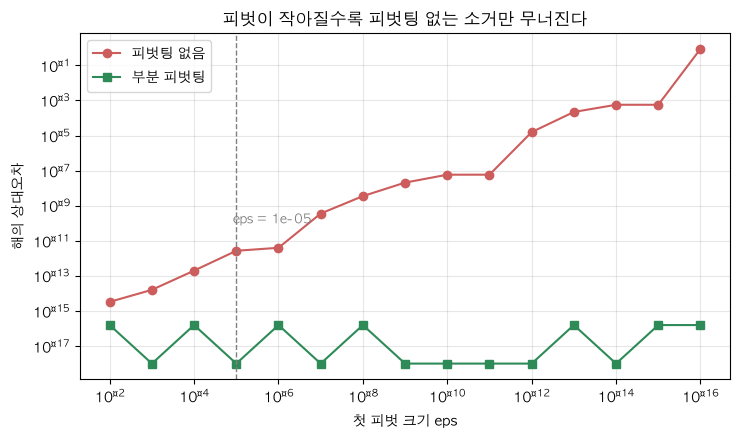

In [12]:
# --- 그래프 (제공 코드) ---
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(eps_list, errs_no, "o-", color="indianred", label="피벗팅 없음")
ax.loglog(eps_list, errs_pp, "s-", color="seagreen", label="부분 피벗팅")
ax.axvline(EPS, ls="--", color="gray", lw=1)
ax.text(EPS * 1.2, 1e-10, "eps = {:g}".format(EPS), color="gray", fontsize=9)
ax.invert_xaxis()
ax.set_xlabel("첫 피벗 크기 eps")
ax.set_ylabel("해의 상대오차")
ax.set_title("피벗이 작아질수록 피벗팅 없는 소거만 무너진다")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
plt.show()

In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다", err_no > err_pp)
ok &= check("부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)", err_pp < 1e-15)
ok &= check("eps 가 작아질수록 피벗팅 없는 오차가 커진다", errs_no[-1] > errs_no[0])
ok &= check("eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)", errs_no[-1] > 0.1)
ok &= check("부분 피벗팅은 eps 와 무관하게 안정적", max(errs_pp) < 1e-14)
ok &= check("피벗팅 결과는 np.linalg.solve 와 일치",                                          # 비교 대상
            np.allclose(x_pp, np.linalg.solve(np.array([[EPS, 1.0], [1.0, 1.0]]), [1.0, 2.0])))
print("\n4-4 전체 통과:", ok)

[PASS] eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다
[PASS] 부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)
[PASS] eps 가 작아질수록 피벗팅 없는 오차가 커진다
[PASS] eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)
[PASS] 부분 피벗팅은 eps 와 무관하게 안정적
[PASS] 피벗팅 결과는 np.linalg.solve 와 일치

4-4 전체 통과: True


## 4-5. 800x800 — `solve` vs `역행렬을 구해서 곱하기`

**할 일**

- 800x800 무작위 행렬에서 `np.linalg.solve(A, b)` 와 `np.linalg.inv(A) @ b` 의
  **실행 시간과 잔차**를 각각 측정해 표와 막대그래프(제공)로 비교하세요.
- 벤치마크는 **워밍업 1회 후 여러 번 재서 최솟값**을 씁니다. (`bench` 제공)
  평균 대신 최솟값을 쓰는 이유도 생각해 보세요.
- 조건수가 좋은 행렬에서는 잔차 차이가 잘 안 보입니다.
  조건수를 지정한 행렬을 만들어(예: SVD 형태로 조립) 조건수별 오차를 비교해 보세요.
- 두 방법의 **연산량**이 각각 얼마인지 조사해 표로 정리하고,
  실무에서 어느 쪽을 써야 하는지 근거와 함께 결론을 쓰세요.

### 결론 — 실무에서는 무엇을 쓰는가

- 연산량: `solve는 분해와 대입을 수행하고, inverse 방식은 역행렬 계산 뒤 곱셈까지 추가한다.`
- 정확도: `일반적으로 solve가 더 안정적이며 역행렬을 명시적으로 만들지 않는다.`
- 메모리: `inverse 방식은 전체 역행렬을 저장해야 하므로 더 많이 사용한다.`
- 우변이 여러 개일 때는: `같은 분해를 재사용하는 solve를 사용한다.`
- 예외적으로 역행렬을 명시적으로 구해야 하는 경우: `역변환 행렬 자체가 필요하거나 여러 계산에서 반복적으로 재사용할 때다.`

In [14]:
N = 800
A_big = np.eye(N) + 1e-3 * rng.standard_normal((N, N))
b_big = rng.standard_normal(N)
REPEAT = 10

def bench(fn, repeat=REPEAT):
    fn()
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, time.perf_counter() - t0)
    return best, out

t_solve, x_solve = bench(lambda: np.linalg.solve(A_big, b_big))
t_inv, x_inv = bench(lambda: np.linalg.inv(A_big) @ b_big)
res_solve = np.linalg.norm(A_big @ x_solve - b_big)
res_inv = np.linalg.norm(A_big @ x_inv - b_big)
print(f"solve={t_solve*1e3:.3f} ms, inverse={t_inv*1e3:.3f} ms")
print(f"residual solve={res_solve:.3e}, inverse={res_inv:.3e}")


solve=2.309 ms, inverse=6.799 ms
residual solve=4.754e-14, inverse=4.233e-14


In [15]:
def make_conditioned(n, condition, generator):
    Q1, _ = np.linalg.qr(generator.standard_normal((n, n)))
    Q2, _ = np.linalg.qr(generator.standard_normal((n, n)))
    singular_values = np.logspace(0, -np.log10(condition), n)
    return (Q1 * singular_values) @ Q2.T

condition_numbers, solve_errors, inverse_errors = [], [], []
x_true = np.ones(200)
for condition in [1e2, 1e6, 1e10, 1e13]:
    conditioned = make_conditioned(200, condition, rng)
    observation = conditioned @ x_true
    solve_error = np.linalg.norm(np.linalg.solve(conditioned, observation) - x_true) / np.linalg.norm(x_true)
    inverse_error = np.linalg.norm(np.linalg.inv(conditioned) @ observation - x_true) / np.linalg.norm(x_true)
    condition_numbers.append(condition); solve_errors.append(solve_error); inverse_errors.append(inverse_error)
    print(f"cond={condition:.0e}: solve={solve_error:.3e}, inverse={inverse_error:.3e}")


cond=1e+02: solve=1.266e-14, inverse=4.857e-14
cond=1e+06: solve=2.164e-11, inverse=2.465e-10
cond=1e+10: solve=8.795e-08, inverse=1.141e-06
cond=1e+13: solve=5.746e-05, inverse=1.827e-03


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


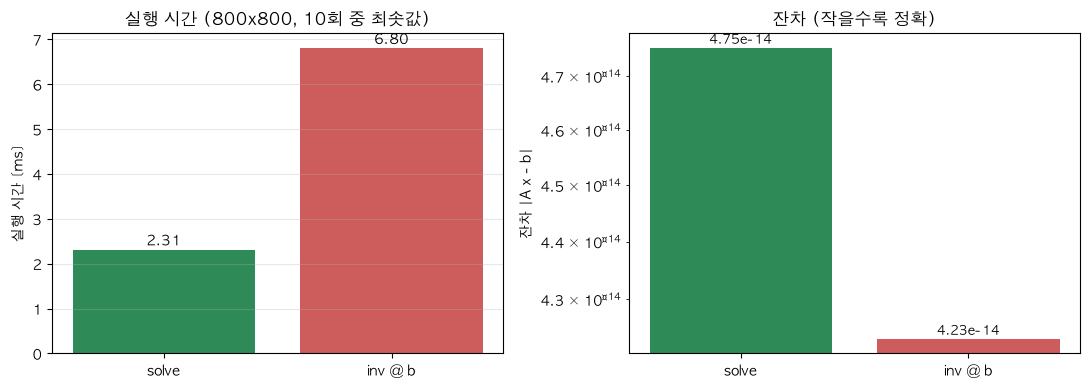

In [16]:
# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = ["solve", "inv @ b"]

axes[0].bar(names, [t_solve * 1e3, t_inv * 1e3], color=["seagreen", "indianred"])
axes[0].set_ylabel("실행 시간 [ms]")
axes[0].set_title("실행 시간 ({0}x{0}, {1}회 중 최솟값)".format(N, REPEAT))
for i, v in enumerate([t_solve * 1e3, t_inv * 1e3]):
    axes[0].text(i, v, "{:.2f}".format(v), ha="center", va="bottom")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(names, [res_solve, res_inv], color=["seagreen", "indianred"])
axes[1].set_ylabel("잔차 |A x - b|")
axes[1].set_yscale("log")
axes[1].set_title("잔차 (작을수록 정확)")
for i, v in enumerate([res_solve, res_inv]):
    axes[1].text(i, v, "{:.2e}".format(v), ha="center", va="bottom", fontsize=9)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

In [17]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("두 방법의 해가 사실상 같다", np.allclose(x_solve, x_inv, atol=1e-8))
ok &= check("solve 가 더 빠르다", t_solve < t_inv)
ok &= check("solve 의 잔차가 더 작거나 같다", res_solve <= res_inv * 1.5)
ok &= check("두 해 모두 유효 (잔차가 작다)", res_solve < 1e-8 and res_inv < 1e-8)
print("\n4-5 전체 통과:", ok)

[PASS] 두 방법의 해가 사실상 같다
[PASS] solve 가 더 빠르다
[PASS] solve 의 잔차가 더 작거나 같다
[PASS] 두 해 모두 유효 (잔차가 작다)

4-5 전체 통과: True


## 답안 템플릿 정리

In [18]:
summary = f"""
1. 최종 해: {x}
2. rank A={rA}, rank [A|b]={rAb}; 두 rank가 n과 같아 유일해다.
3. det(A)={detA:.1f}; 역행렬은 가우스-조던으로 직접 계산했다.
4. eps={EPS:.0e}에서 no-pivot 오차={err_no:.3e}, partial-pivot 오차={err_pp:.3e}; 작은 피벗은 유효숫자를 잃게 한다.
5. solve={t_solve*1e3:.3f} ms, inverse 방식={t_inv*1e3:.3f} ms; 일반 문제에서는 solve를 선택한다.
"""
print(summary)



1. 최종 해: [ 2. -1.  3.]
2. rank A=3, rank [A|b]=3; 두 rank가 n과 같아 유일해다.
3. det(A)=42.0; 역행렬은 가우스-조던으로 직접 계산했다.
4. eps=1e-05에서 no-pivot 오차=2.690e-12, partial-pivot 오차=0.000e+00; 작은 피벗은 유효숫자를 잃게 한다.
5. solve=2.309 ms, inverse 방식=6.799 ms; 일반 문제에서는 solve를 선택한다.

